In [4]:
#importing relavet libs
import ast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#loading spesific dataset
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')

#changing to data frame
df = dataset['train'].to_pandas()

#cleaning data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



In [5]:
#top 10 paid skills for data analyst
#top 10 skills in demmand for data analyst

df_data_analyst = df[
    (df['job_title_short'] == 'Data Analyst')
      & 
    (df['job_country'] == 'United States')]
#sorts for only Data Analyst in the United States
df_data_analyst = df_data_analyst[df_data_analyst['salary_year_avg'].notna()]
#df_data_analyst.info()
df_data_analyst = df_data_analyst.explode('job_skills')
# df_data_analyst.head(5)


In [6]:
# # Initialize empty list to store data
# data_list = []

# # Loop through each unique skill
# for unique_skill in df_data_analyst['job_skills'].unique():
#     median_salary = df_data_analyst.loc[
#         df_data_analyst['job_skills'] == unique_skill, 'salary_year_avg'
#     ].median()
    
#     skill_count = df_data_analyst.loc[
#         df_data_analyst['job_skills'] == unique_skill, 'job_skills'
#     ].count()
    
#     data_list.append({
#         'job_skill': unique_skill,
#         'median_salary': median_salary,
#         'count': skill_count
#     })

# # Convert list of dicts into a DataFrame
# df_skills_summary = pd.DataFrame(data_list)

In [7]:
df_skills_summary = (
    df_data_analyst
    .groupby('job_skills')
    .agg(median_salary=('salary_year_avg', 'median'),
         count=('job_skills', 'count'))
    .reset_index()
)

In [8]:
# Top 10 most in-demand skills by count
top5_demand = df_skills_summary.sort_values(by='count', ascending=False).head(10)

# Top 10 highest paying skills by median_salary
top5_salary = (
    df_skills_summary[df_skills_summary['count'] >= 5]   # keep only skills with >= 5 posts
    .sort_values(by='median_salary', ascending=False)    # sort by salary
    .head(10)                                             # take top 5
)


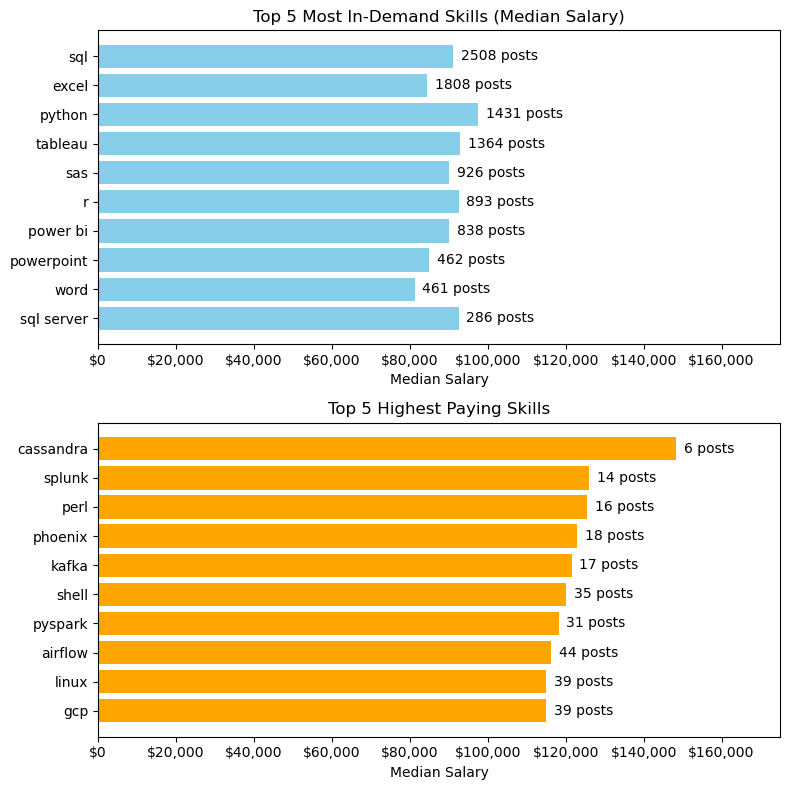

In [9]:
import matplotlib.ticker as ticker

# -------- Plot --------
fig, axes = plt.subplots(2, 1, figsize=(8,8))

# Format salaries as American money (with commas and $)
formatter = ticker.StrMethodFormatter("${x:,.0f}")



# --- Left chart: Top 5 in demand (bars = median salary) ---
axes[0].barh(top5_demand['job_skills'], top5_demand['median_salary'], color='skyblue')
axes[0].set_title("Top 5 Most In-Demand Skills (Median Salary)")
axes[0].set_xlabel("Median Salary")
axes[0].invert_yaxis()  # so highest demand skill is on top
axes[0].set_xlim(0, 175000)  # show x-axis only between
axes[0].xaxis.set_major_formatter(formatter)

# Add count labels next to bars
for i, (val, cnt) in enumerate(zip(top5_demand['median_salary'], top5_demand['count'])):
    axes[0].text(val + 2000, i, f"{cnt} posts", va='center', ha='left', fontsize=10)

# --- Right chart: Top 5 highest paying skills ---
axes[1].barh(top5_salary['job_skills'], top5_salary['median_salary'], color='orange')
axes[1].set_title("Top 5 Highest Paying Skills")
axes[1].set_xlabel("Median Salary")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(formatter)
axes[1].set_xlim(axes[0].get_xlim())  # show x-axis only between


# Add count labels next to bars
for i, (val, cnt) in enumerate(zip(top5_salary['median_salary'], top5_salary['count'])):
    axes[1].text(val + 2000, i, f"{cnt} posts", va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()